# Analise exploratoria do experimento Edge-Cloud

Este notebook complementa o projeto C#/.NET. O C# continua sendo o pipeline principal: ele gera o dataset, simula Edge/Cloud, treina as estrategias implementadas e produz os resultados oficiais.

Aqui o objetivo e investigar os dados com mais liberdade e comparar modelos externos de Machine Learning.

## Objetivos deste notebook

1. Carregar `dataset.csv`, `train.csv` e `test.csv`.
2. Entender a distribuicao das features.
3. Verificar o balanceamento entre `Edge` e `Cloud`.
4. Investigar quando Edge ganha e quando Cloud ganha.
5. Medir correlacoes entre variaveis.
6. Treinar modelos externos com `scikit-learn`.
7. Comparar esses modelos com os resultados do projeto C#.
8. Levantar hipoteses para melhorar a WiSARD.

## 0. Instalacao das dependencias

Se alguma biblioteca estiver faltando, execute no terminal:

```bash
pip install pandas numpy matplotlib seaborn scikit-learn
```

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 140)

## 1. Carregamento dos dados

Este notebook foi criado dentro da pasta `notebooks/`. Por isso, os CSVs sao acessados voltando uma pasta e entrando em `Dataset/`.

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()
DATASET_DIR = PROJECT_ROOT / "Dataset"

dataset_path = DATASET_DIR / "dataset.csv"
train_path = DATASET_DIR / "train.csv"
test_path = DATASET_DIR / "test.csv"

print("Project root:", PROJECT_ROOT)
print("Dataset existe?", dataset_path.exists(), dataset_path)
print("Train existe?", train_path.exists(), train_path)
print("Test existe?", test_path.exists(), test_path)

Project root: c:\Users\Antonny\Documents\Codex\2026-06-07\files-mentioned-by-the-user-texto\outputs\EdgeCloudOffloadingTcc
Dataset existe? True c:\Users\Antonny\Documents\Codex\2026-06-07\files-mentioned-by-the-user-texto\outputs\EdgeCloudOffloadingTcc\Dataset\dataset.csv
Train existe? True c:\Users\Antonny\Documents\Codex\2026-06-07\files-mentioned-by-the-user-texto\outputs\EdgeCloudOffloadingTcc\Dataset\train.csv
Test existe? True c:\Users\Antonny\Documents\Codex\2026-06-07\files-mentioned-by-the-user-texto\outputs\EdgeCloudOffloadingTcc\Dataset\test.csv


In [3]:
df = pd.read_csv(dataset_path)
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(df.shape, train_df.shape, test_df.shape)
df.head()

(15000, 17) (12000, 17) (3000, 17)


,CpuCycles,TaskSizeMB,DeadlineMs,LatencySensitivity,RequiredMemoryMB,EdgeCpuUsagePercent,EdgeMemoryUsagePercent,EdgeQueueSize,BandwidthMbps,NetworkLatencyMs,CloudCpuUsagePercent,CloudQueueSize,ExecutionTimeEdge,ExecutionTimeCloud,TotalResponseTimeEdge,TotalResponseTimeCloud,BestDestination
0,5.361446e+09,0.28024,796.83382,0.52276,1088.08008,29.42112,72.29912,13,5.88450,137.50260,24.94002,10,578.23699,101.73842,984.35054,846.98187,Cloud
1,4.069548e+09,1.04014,2316.76920,0.26024,3210.10269,8.28465,80.01581,15,23.64781,29.09037,12.65957,28,636.77960,72.59606,962.70099,819.11533,Cloud
2,6.538647e+09,5.18795,312.67547,0.71115,962.38850,89.27779,69.56272,13,6.36883,9.38877,31.19697,23,1031.35045,127.86503,1787.62550,7048.46103,Edge
3,6.577468e+09,0.10293,3237.54602,0.80518,4614.02228,40.76535,22.82424,0,2.74601,141.13244,58.24879,4,771.56633,145.09943,771.56633,791.00963,Edge
4,2.037189e+09,28.39899,1773.15974,0.64815,937.37063,9.13835,61.99210,13,2.74235,76.82518,65.05950,25,185.27950,46.22522,472.73883,83626.28175,Edge


## 2. Visao geral do dataset

Aqui verificamos tipos, valores ausentes e estatisticas basicas. Isso ajuda a descobrir problemas antes de treinar modelos.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CpuCycles               15000 non-null  float64
 1   TaskSizeMB              15000 non-null  float64
 2   DeadlineMs              15000 non-null  float64
 3   LatencySensitivity      15000 non-null  float64
 4   RequiredMemoryMB        15000 non-null  float64
 5   EdgeCpuUsagePercent     15000 non-null  float64
 6   EdgeMemoryUsagePercent  15000 non-null  float64
 7   EdgeQueueSize           15000 non-null  int64  
 8   BandwidthMbps           15000 non-null  float64
 9   NetworkLatencyMs        15000 non-null  float64
 10  CloudCpuUsagePercent    15000 non-null  float64
 11  CloudQueueSize          15000 non-null  int64  
 12  ExecutionTimeEdge       15000 non-null  float64
 13  ExecutionTimeCloud      15000 non-null  float64
 14  TotalResponseTimeEdge   15000 non-null  float64
 

In [5]:
df.isna().sum().sort_values(ascending=False)

CpuCycles                 0
TaskSizeMB                0
DeadlineMs                0
LatencySensitivity        0
RequiredMemoryMB          0
EdgeCpuUsagePercent       0
EdgeMemoryUsagePercent    0
EdgeQueueSize             0
BandwidthMbps             0
NetworkLatencyMs          0
CloudCpuUsagePercent      0
CloudQueueSize            0
ExecutionTimeEdge         0
ExecutionTimeCloud        0
TotalResponseTimeEdge     0
TotalResponseTimeCloud    0
BestDestination           0
dtype: int64

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CpuCycles,15000.0,4.022296e+09,2.302628e+09,5.048266e+07,2.025984e+09,4.042653e+09,6.021040e+09,7.999929e+09
TaskSizeMB,15000.0,2.007305e+01,3.302231e+01,1.000000e-01,6.146375e-01,3.668755e+00,2.340663e+01,1.499912e+02
DeadlineMs,15000.0,3.019048e+03,1.713891e+03,5.076006e+01,1.557710e+03,3.001710e+03,4.519435e+03,5.999990e+03
LatencySensitivity,15000.0,5.028759e-01,2.877256e-01,1.000000e-05,2.559550e-01,5.003350e-01,7.562225e-01,9.999100e-01
RequiredMemoryMB,15000.0,3.111922e+03,1.751229e+03,6.413169e+01,1.593214e+03,3.140682e+03,4.612473e+03,6.143791e+03
EdgeCpuUsagePercent,15000.0,5.176180e+01,2.694213e+01,5.001460e+00,2.868767e+01,5.168002e+01,7.526401e+01,9.799385e+01
EdgeMemoryUsagePercent,15000.0,5.300496e+01,2.481978e+01,1.000738e+01,3.138393e+01,5.287018e+01,7.455882e+01,9.599379e+01
EdgeQueueSize,15000.0,1.248860e+01,7.562897e+00,0.000000e+00,6.000000e+00,1.300000e+01,1.900000e+01,2.500000e+01
BandwidthMbps,15000.0,1.572501e+02,2.301133e+02,2.001070e+00,9.115077e+00,4.369561e+01,2.062846e+02,9.991420e+02
NetworkLatencyMs,15000.0,9.082155e+01,5.138268e+01,2.024540e+00,4.625597e+01,9.107612e+01,1.357266e+02,1.799684e+02


## 3. Balanceamento das classes

A classe alvo e `BestDestination`. Se uma classe aparecer muito mais que a outra, accuracy sozinha pode enganar.

,count,percent
BestDestination,,
Edge,9362,62.41
Cloud,5638,37.59


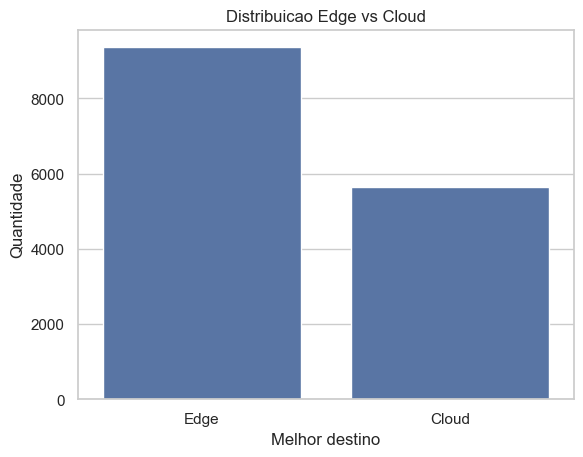

In [7]:
class_counts = df["BestDestination"].value_counts()
class_percent = df["BestDestination"].value_counts(normalize=True).mul(100)

display(pd.DataFrame({"count": class_counts, "percent": class_percent.round(2)}))

ax = sns.countplot(data=df, x="BestDestination", order=["Edge", "Cloud"])
ax.set_title("Distribuicao Edge vs Cloud")
ax.set_xlabel("Melhor destino")
ax.set_ylabel("Quantidade")
plt.show()

## 4. Distribuicao das features

Estas figuras ajudam a entender a faixa de valores gerada pelo simulador. Variaveis como `CpuCycles`, `TaskSizeMB` e `BandwidthMbps` podem ter distribuicao assimetrica.

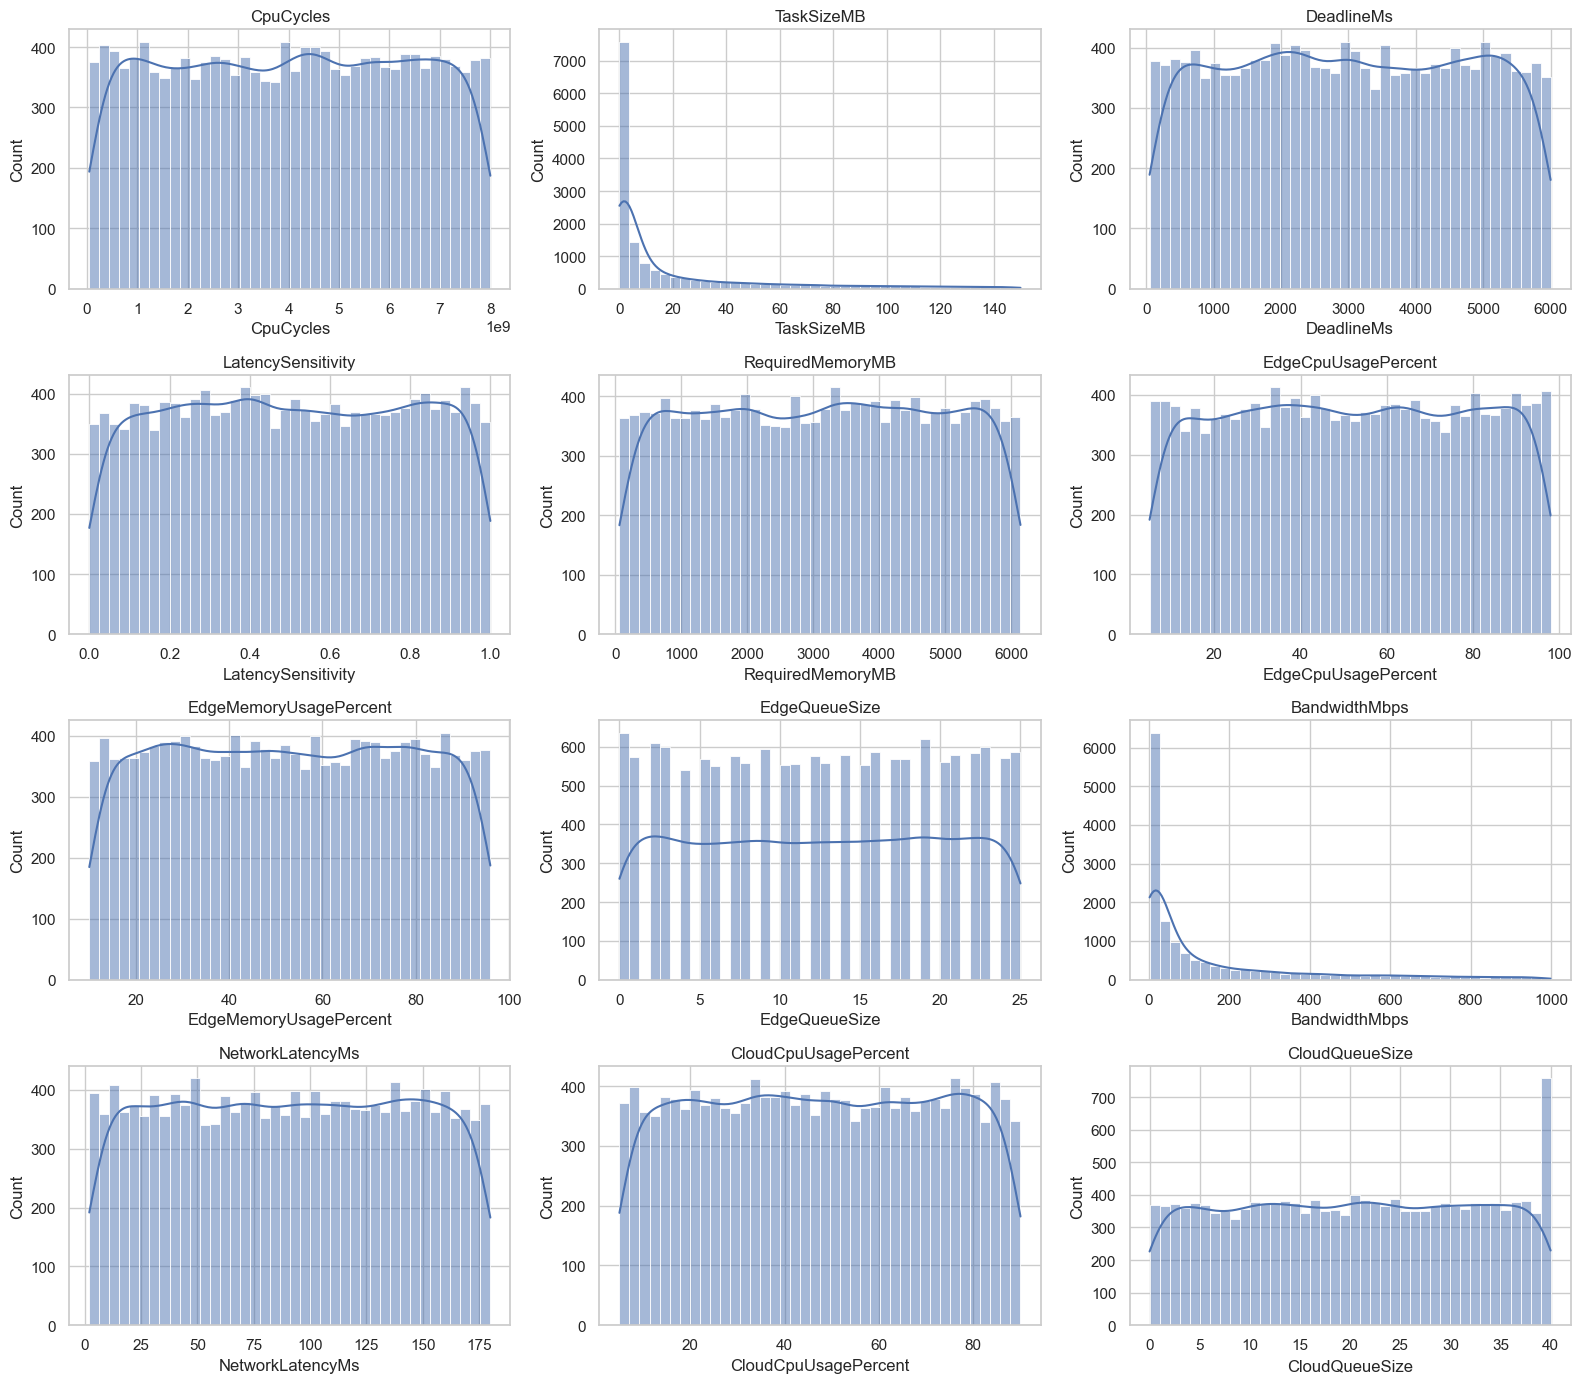

In [8]:
feature_cols = [
    "CpuCycles", "TaskSizeMB", "DeadlineMs", "LatencySensitivity", "RequiredMemoryMB",
    "EdgeCpuUsagePercent", "EdgeMemoryUsagePercent", "EdgeQueueSize",
    "BandwidthMbps", "NetworkLatencyMs", "CloudCpuUsagePercent", "CloudQueueSize",
]

fig, axes = plt.subplots(4, 3, figsize=(16, 14))
axes = axes.ravel()

for ax, col in zip(axes, feature_cols):
    sns.histplot(df[col], bins=40, kde=True, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

## 5. Quando Edge ganha e quando Cloud ganha?

Nesta parte comparamos as features agrupadas por `BestDestination`. Isso ajuda a entender o comportamento aprendido pelos modelos.

In [9]:
group_summary = df.groupby("BestDestination")[feature_cols + [
    "ExecutionTimeEdge", "ExecutionTimeCloud", "TotalResponseTimeEdge", "TotalResponseTimeCloud"
]].mean().T

group_summary["Cloud_minus_Edge"] = group_summary.get("Cloud", np.nan) - group_summary.get("Edge", np.nan)
group_summary

BestDestination,Cloud,Edge,Cloud_minus_Edge
CpuCycles,4.639026e+09,3.650889e+09,9.881367e+08
TaskSizeMB,4.444423e+00,2.948494e+01,-2.504052e+01
DeadlineMs,3.086609e+03,2.978361e+03,1.082480e+02
LatencySensitivity,5.010718e-01,5.039623e-01,-2.890573e-03
RequiredMemoryMB,3.276341e+03,3.012905e+03,2.634361e+02
EdgeCpuUsagePercent,5.794309e+01,4.803930e+01,9.903798e+00
EdgeMemoryUsagePercent,5.536164e+01,5.158572e+01,3.775916e+00
EdgeQueueSize,1.456527e+01,1.123798e+01,3.327288e+00
BandwidthMbps,2.515862e+02,1.004389e+02,1.511473e+02
NetworkLatencyMs,8.762021e+01,9.274947e+01,-5.129258e+00


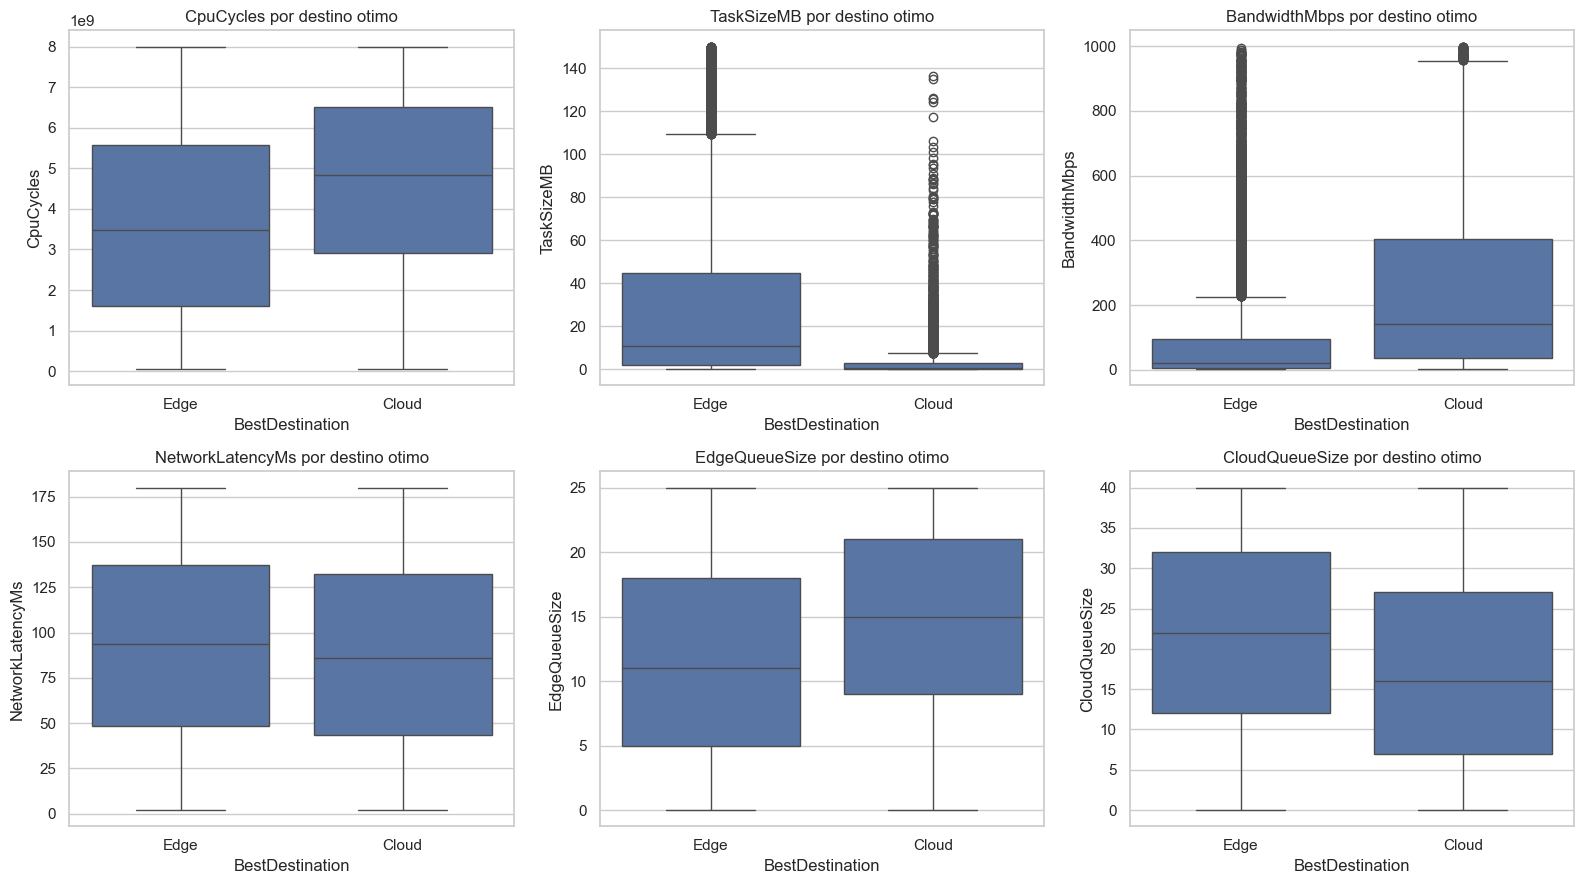

In [10]:
selected_cols = ["CpuCycles", "TaskSizeMB", "BandwidthMbps", "NetworkLatencyMs", "EdgeQueueSize", "CloudQueueSize"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for ax, col in zip(axes, selected_cols):
    sns.boxplot(data=df, x="BestDestination", y=col, order=["Edge", "Cloud"], ax=ax)
    ax.set_title(f"{col} por destino otimo")

plt.tight_layout()
plt.show()

## 6. Comparacao direta dos tempos simulados

A diferenca entre `TotalResponseTimeCloud` e `TotalResponseTimeEdge` mostra a margem de vantagem de uma decisao sobre a outra.

,count,mean,std,min,25%,50%,75%,max
TotalResponseTimeEdge,15000.0,1192.774433,637.889514,7.56275,725.010295,1099.571230,1557.521110,4418.04316
TotalResponseTimeCloud,15000.0,13596.063069,42607.298511,49.86933,779.056398,1406.244735,5758.063145,531685.77236
CloudMinusEdgeMs,15000.0,12403.288636,42618.748652,-3741.58982,-380.142405,428.428595,4599.888673,530972.47256


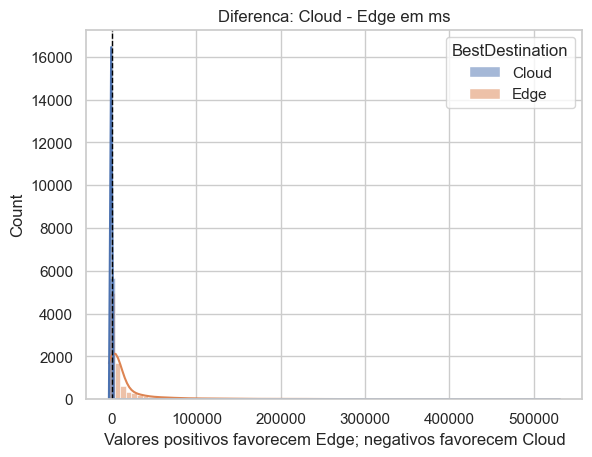

In [11]:
df["CloudMinusEdgeMs"] = df["TotalResponseTimeCloud"] - df["TotalResponseTimeEdge"]

display(df[["TotalResponseTimeEdge", "TotalResponseTimeCloud", "CloudMinusEdgeMs", "BestDestination"]].describe().T)

ax = sns.histplot(data=df, x="CloudMinusEdgeMs", hue="BestDestination", bins=80, kde=True)
ax.axvline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Diferenca: Cloud - Edge em ms")
ax.set_xlabel("Valores positivos favorecem Edge; negativos favorecem Cloud")
plt.show()

## 7. Correlacoes

As correlacoes ajudam a identificar quais variaveis estao mais associadas ao destino ideal. Como a classe e textual, criamos `TargetCloud`: Edge = 0 e Cloud = 1.

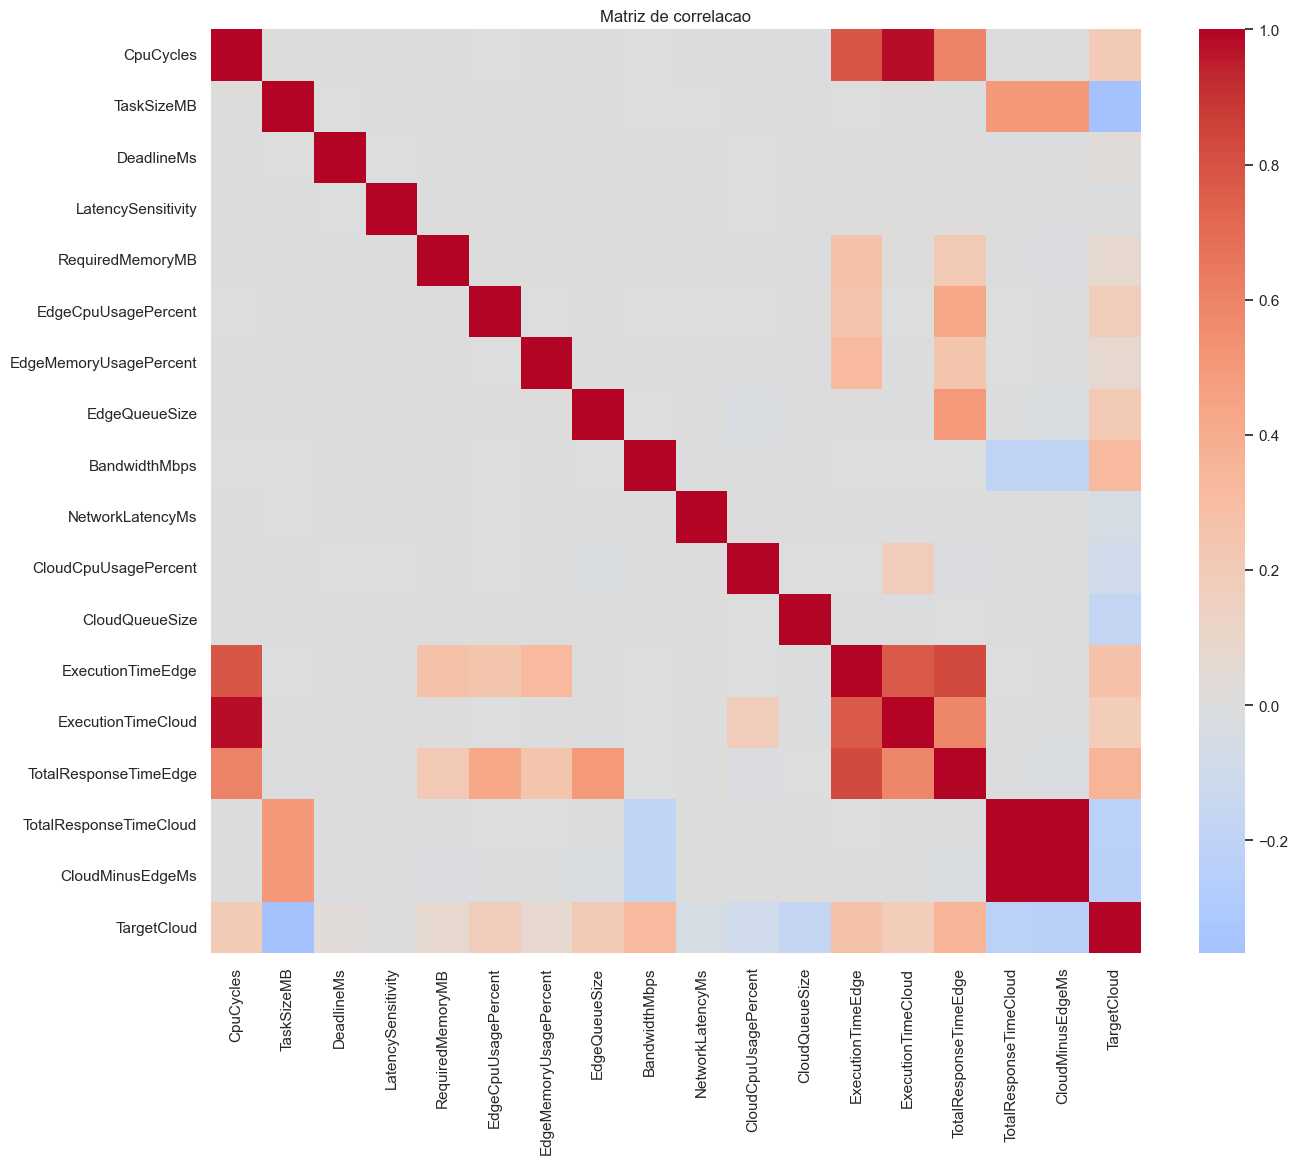

TargetCloud               1.000000
TotalResponseTimeEdge     0.357830
BandwidthMbps             0.318148
ExecutionTimeEdge         0.270587
EdgeQueueSize             0.213095
CpuCycles                 0.207856
ExecutionTimeCloud        0.185863
EdgeCpuUsagePercent       0.178049
EdgeMemoryUsagePercent    0.073688
RequiredMemoryMB          0.072862
DeadlineMs                0.030592
LatencySensitivity       -0.004866
NetworkLatencyMs         -0.048351
CloudCpuUsagePercent     -0.098695
CloudQueueSize           -0.172133
TotalResponseTimeCloud   -0.233433
CloudMinusEdgeMs         -0.238726
TaskSizeMB               -0.367287
Name: TargetCloud, dtype: float64

In [12]:
corr_df = df.copy()
corr_df["TargetCloud"] = (corr_df["BestDestination"] == "Cloud").astype(int)

corr_cols = feature_cols + ["ExecutionTimeEdge", "ExecutionTimeCloud", "TotalResponseTimeEdge", "TotalResponseTimeCloud", "CloudMinusEdgeMs", "TargetCloud"]
corr = corr_df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(15, 12))
sns.heatmap(corr, cmap="coolwarm", center=0, square=False)
plt.title("Matriz de correlacao")
plt.show()

corr["TargetCloud"].sort_values(ascending=False)

## 8. Preparacao para modelos externos

Agora usamos `train.csv` e `test.csv`, mantendo a mesma divisao produzida pelo projeto C#.

In [13]:
X_train = train_df[feature_cols]
y_train = (train_df["BestDestination"] == "Cloud").astype(int)

X_test = test_df[feature_cols]
y_test = (test_df["BestDestination"] == "Cloud").astype(int)

print(X_train.shape, X_test.shape)
print("Treino:")
print(y_train.value_counts(normalize=True).rename({0: "Edge", 1: "Cloud"}))
print("Teste:")
print(y_test.value_counts(normalize=True).rename({0: "Edge", 1: "Cloud"}))

(12000, 12) (3000, 12)
Treino:
BestDestination
Edge     0.624167
Cloud    0.375833
Name: proportion, dtype: float64
Teste:
BestDestination
Edge     0.624
Cloud    0.376
Name: proportion, dtype: float64


## 9. Treinamento de modelos com scikit-learn

Estes modelos nao substituem o projeto C#. Eles servem como comparacao cientifica externa.

In [14]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)),
    ]),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=250, max_depth=None, class_weight="balanced", random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "MLP sklearn": Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(hidden_layer_sizes=(32, 16), activation="relu", max_iter=500, random_state=42)),
    ]),
}

results = []
trained_models = {}

for name, model in models.items():
    print(f"Treinando {name}...")
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    trained_models[name] = model
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
    })

results_df = pd.DataFrame(results).sort_values("F1", ascending=False)
results_df

Treinando Logistic Regression...
Treinando Decision Tree...
Treinando Random Forest...
Treinando Gradient Boosting...
Treinando MLP sklearn...


,Model,Accuracy,Precision,Recall,F1
4,MLP sklearn,0.962333,0.938634,0.962766,0.950547
3,Gradient Boosting,0.952333,0.940913,0.931738,0.936303
2,Random Forest,0.949667,0.917165,0.952128,0.934319
1,Decision Tree,0.881000,0.805226,0.901596,0.850690
0,Logistic Regression,0.850333,0.765857,0.867021,0.813306


## 10. Comparacao com os resultados do C#

A tabela abaixo inclui os resultados da ultima execucao do projeto C# anotados manualmente. Se voce rodar o C# novamente com outra seed ou outro tamanho, atualize estes valores.

In [15]:
csharp_results = pd.DataFrame([
    {"Model": "C# Random Decision", "Accuracy": 0.5080, "Precision": np.nan, "Recall": np.nan, "F1": 0.4366},
    {"Model": "C# Fixed Rule", "Accuracy": 0.5700, "Precision": np.nan, "Recall": np.nan, "F1": 0.5442},
    {"Model": "C# Simple Heuristic", "Accuracy": 0.7123, "Precision": np.nan, "Recall": np.nan, "F1": 0.6326},
    {"Model": "C# WiSARD", "Accuracy": 0.6300, "Precision": np.nan, "Recall": np.nan, "F1": 0.0415},
    {"Model": "C# MLP", "Accuracy": 0.9337, "Precision": np.nan, "Recall": np.nan, "F1": 0.9089},
])

comparison_df = pd.concat([csharp_results, results_df], ignore_index=True).sort_values("F1", ascending=False)
comparison_df

,Model,Accuracy,Precision,Recall,F1
5,MLP sklearn,0.962333,0.938634,0.962766,0.950547
6,Gradient Boosting,0.952333,0.940913,0.931738,0.936303
7,Random Forest,0.949667,0.917165,0.952128,0.934319
4,C# MLP,0.933700,NaN,NaN,0.908900
8,Decision Tree,0.881000,0.805226,0.901596,0.850690
9,Logistic Regression,0.850333,0.765857,0.867021,0.813306
2,C# Simple Heuristic,0.712300,NaN,NaN,0.632600
1,C# Fixed Rule,0.570000,NaN,NaN,0.544200
0,C# Random Decision,0.508000,NaN,NaN,0.436600
3,C# WiSARD,0.630000,NaN,NaN,0.041500


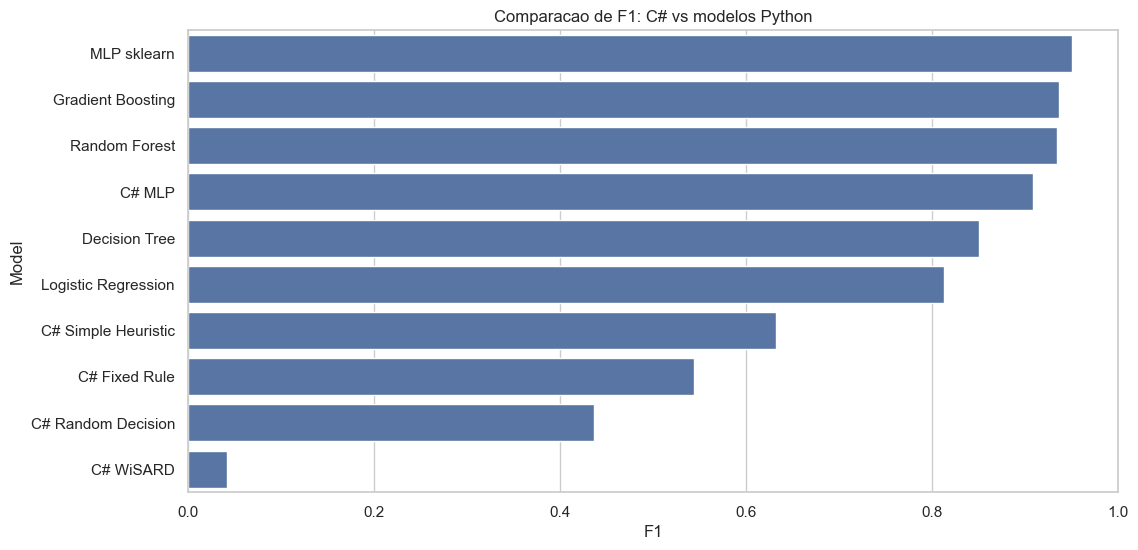

In [16]:
plt.figure(figsize=(12, 6))
sns.barplot(data=comparison_df, x="F1", y="Model")
plt.title("Comparacao de F1: C# vs modelos Python")
plt.xlim(0, 1)
plt.show()

## 11. Matriz de confusao do melhor modelo Python

Esta etapa mostra onde o melhor modelo externo acerta e erra.

Melhor modelo Python: MLP sklearn
              precision    recall  f1-score   support

        Edge       0.98      0.96      0.97      1872
       Cloud       0.94      0.96      0.95      1128

    accuracy                           0.96      3000
   macro avg       0.96      0.96      0.96      3000
weighted avg       0.96      0.96      0.96      3000



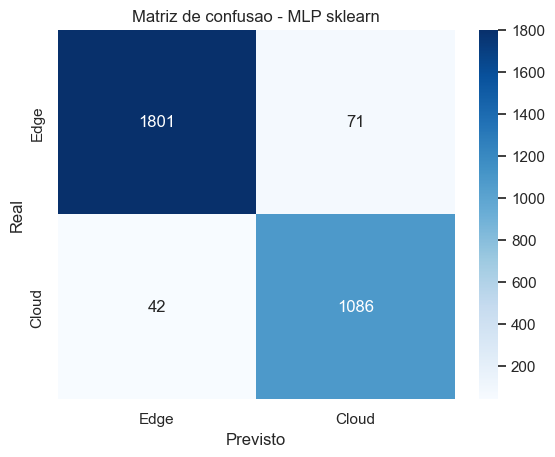

In [17]:
best_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_name]
best_pred = best_model.predict(X_test)

print("Melhor modelo Python:", best_name)
print(classification_report(y_test, best_pred, target_names=["Edge", "Cloud"], zero_division=0))

cm = confusion_matrix(y_test, best_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Edge", "Cloud"], yticklabels=["Edge", "Cloud"])
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.title(f"Matriz de confusao - {best_name}")
plt.show()

## 12. Latencia obtida pelos modelos Python

Nem sempre o maior F1 e o menor tempo medio de resposta. Aqui calculamos a latencia media escolhida e a perda quando o modelo erra.

In [18]:
def offloading_efficiency_metrics(test_data: pd.DataFrame, pred_binary: np.ndarray) -> dict:
    pred_destination = np.where(pred_binary == 1, "Cloud", "Edge")
    chosen_latency = np.where(
        pred_destination == "Cloud",
        test_data["TotalResponseTimeCloud"],
        test_data["TotalResponseTimeEdge"],
    )
    optimal_latency = np.minimum(test_data["TotalResponseTimeCloud"], test_data["TotalResponseTimeEdge"])
    loss = chosen_latency - optimal_latency
    incorrect_loss = loss[loss > 0]
    return {
        "AverageChosenLatencyMs": float(np.mean(chosen_latency)),
        "AverageLossWhenIncorrectMs": float(incorrect_loss.mean()) if len(incorrect_loss) else 0.0,
        "CorrectDecisionPercent": float((loss == 0).mean() * 100),
    }

efficiency_rows = []
for name, model in trained_models.items():
    pred = model.predict(X_test)
    row = {"Model": name}
    row.update(offloading_efficiency_metrics(test_df, pred))
    efficiency_rows.append(row)

efficiency_df = pd.DataFrame(efficiency_rows).sort_values("AverageChosenLatencyMs")
efficiency_df

,Model,AverageChosenLatencyMs,AverageLossWhenIncorrectMs,CorrectDecisionPercent
3,Gradient Boosting,940.499776,176.007172,95.233333
2,Random Forest,941.086092,178.330950,94.966667
4,MLP sklearn,943.978931,315.101690,96.233333
1,Decision Tree,983.417650,431.155877,88.100000
0,Logistic Regression,1294.882143,2423.866647,85.033333


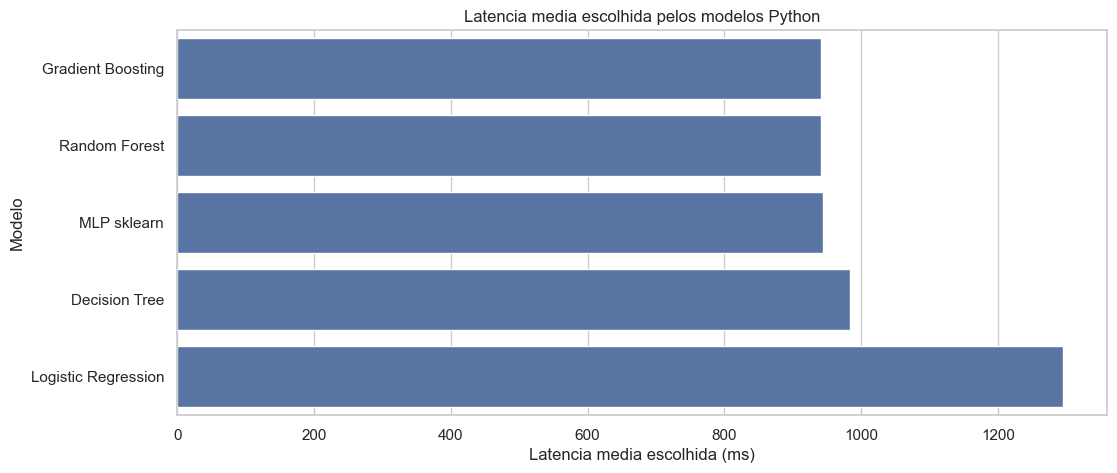

In [19]:
plt.figure(figsize=(12, 5))
sns.barplot(data=efficiency_df, x="AverageChosenLatencyMs", y="Model")
plt.title("Latencia media escolhida pelos modelos Python")
plt.xlabel("Latencia media escolhida (ms)")
plt.ylabel("Modelo")
plt.show()

## 13. Importancia das features

Arvores e florestas permitem estimar quais variaveis foram mais usadas. Isso ajuda a explicar os resultados no TCC.

,Feature,Importance
1,TaskSizeMB,0.321941
8,BandwidthMbps,0.220666
0,CpuCycles,0.086251
7,EdgeQueueSize,0.070815
5,EdgeCpuUsagePercent,0.064410
11,CloudQueueSize,0.056794
10,CloudCpuUsagePercent,0.037592
6,EdgeMemoryUsagePercent,0.032398
4,RequiredMemoryMB,0.031752
9,NetworkLatencyMs,0.027435


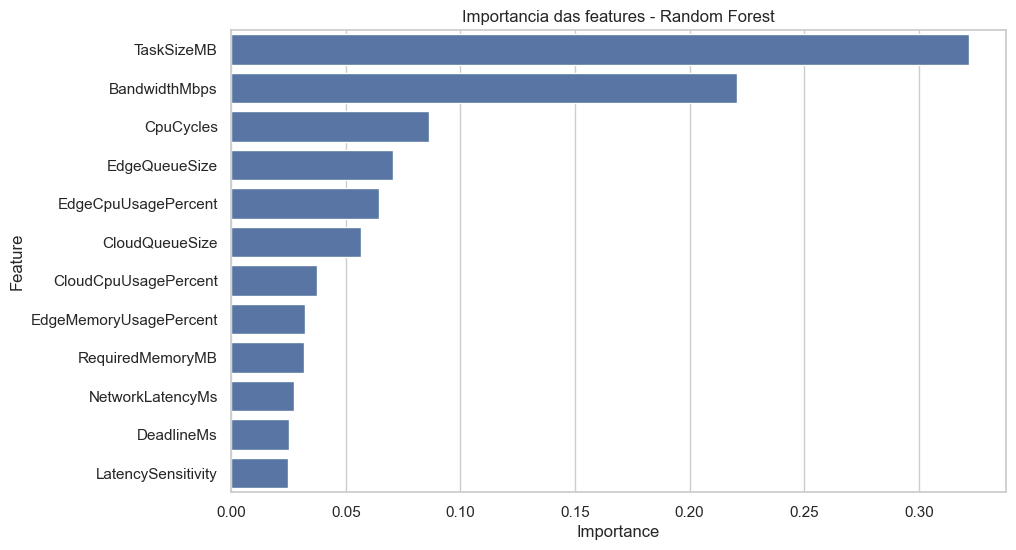

In [20]:
rf = trained_models.get("Random Forest")
if rf is not None and hasattr(rf, "feature_importances_"):
    importances = pd.DataFrame({
        "Feature": feature_cols,
        "Importance": rf.feature_importances_,
    }).sort_values("Importance", ascending=False)
    display(importances)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=importances, x="Importance", y="Feature")
    plt.title("Importancia das features - Random Forest")
    plt.show()

## 14. Investigacao da WiSARD

No resultado atual do C#, a WiSARD teve F1 baixo. Isso sugere que ela pode estar enviesada para prever uma classe com frequencia muito maior.

Pontos para investigar no codigo C#:

- Aumentar `bitsPerFeature`.
- Testar outros valores de `ramAddressSize`.
- Usar balanceamento de classes no treinamento.
- Implementar bleaching.
- Rodar varias seeds para o mapeamento aleatorio.
- Aplicar transformacao logaritmica em `TaskSizeMB`, `BandwidthMbps` e `CpuCycles` antes da binarizacao.

A celula abaixo calcula qual seria o baseline de sempre prever Edge ou sempre prever Cloud.

In [21]:
always_edge = np.zeros_like(y_test)
always_cloud = np.ones_like(y_test)

baseline_rows = []
for name, pred in [("Sempre Edge", always_edge), ("Sempre Cloud", always_cloud)]:
    baseline_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        **offloading_efficiency_metrics(test_df, pred),
    })

pd.DataFrame(baseline_rows)

,Model,Accuracy,Precision,Recall,F1,AverageChosenLatencyMs,AverageLossWhenIncorrectMs,CorrectDecisionPercent
0,Sempre Edge,0.624,0.000,0.0,0.000000,1204.100059,723.377547,62.4
1,Sempre Cloud,0.376,0.376,1.0,0.546512,14507.226458,21754.994161,37.6


## 15. Conclusoes para levar ao TCC

Preencha esta secao apos executar o notebook.

Sugestoes de perguntas para responder:

1. As classes Edge e Cloud estao balanceadas?
2. Quais features mais diferenciam as classes?
3. A MLP em C# continua competitiva contra modelos Python?
4. Algum modelo tem menor latencia media mesmo com F1 menor?
5. A WiSARD esta pior que o baseline de sempre escolher Edge?
6. O simulador parece favorecer demais algum destino?

A partir dessas respostas, voce consegue escrever uma secao de resultados muito mais forte.